The code is inspired by : https://github.com/google-deepmind/deepmind-research/blob/master/enformer/enformer-usage.ipynb

**"Effective gene expression prediction from sequence by integrating long-range interactions"**

Žiga Avsec, Vikram Agarwal, Daniel Visentin, Joseph R. Ledsam, Agnieszka Grabska-Barwinska, Kyle R. Taylor, Yannis Assael, John Jumper, Pushmeet Kohli, David R. Kelley

This colab demonstrates how to
- Make predictions with Enformer and reproduce Fig. 1d
- Compute contribution scores and reproduce parts of Fig. 2a
- Predict the effect of a genetic variant and reproduce parts of Fig. 3g
- Score multiple variants in a VCF

**Start the colab kernel with GPU**: Runtime -> Change runtime type -> GPU

In [1]:
import tensorflow as tf
# Make sure the GPU is enabled
assert tf.config.list_physical_devices('GPU'), 'Start the colab kernel with GPU: Runtime -> Change runtime type -> GPU'

In [2]:
!pip install kipoiseq==0.5.2 --quiet > /dev/null
# You can ignore the pyYAML error

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jsonschema 4.26.0 requires attrs>=22.2.0, but you have attrs 21.4.0 which is incompatible.
referencing 0.37.0 requires attrs>=22.2.0, but you have attrs 21.4.0 which is incompatible.


### Imports

In [3]:
import tensorflow_hub as hub
import joblib
import gzip
import kipoiseq
from kipoiseq import Interval
import pyfaidx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# transform_path = 'gs://dm-enformer/models/enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl'
# model_path = 'https://tfhub.dev/deepmind/enformer/1'
# fasta_file = '/root/data/genome.fa'
# clinvar_vcf = '/root/data/clinvar.vcf.gz'

In [6]:
# Install required genomics libraries
!pip install kipoiseq==0.5.2 pyfaidx --quiet > /dev/null
import kipoiseq
from kipoiseq import Interval
import pyfaidx

# Verify GPU
assert tf.config.list_physical_devices('GPU'), 'Start the colab kernel with GPU: Runtime -> Change runtime type -> GPU'

# 2. DEFINE PATHS BASED ON YOUR GDRIVE FOLDER
BASE_DIR = '/content/drive/MyDrive/Enformer_tutorial_Google_DeepMind'

In [7]:
import tensorflow as tf
import shutil

# gcs_path = "gs://dm-enformer/models/enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl"
# local_path = "enformer.transform.pkl" # Change this to your Google Drive path if needed

# Copy the file from Google Cloud Storage to your local environment
# with tf.io.gfile.GFile(gcs_path, "rb") as f_src:
#    with open(local_path, "wb") as f_dst:
#        shutil.copyfileobj(f_src, f_dst)

# print(f"Downloaded to {local_path}")

In [8]:
!ls -lh ./drive/MyDrive/Enformer_tutorial_Google_DeepMind/data
# !ls -lh /root/data

total 0


In [9]:
BASE_DIR = '/content/drive/MyDrive/Enformer_tutorial_Google_DeepMind'

# Path to the downloaded transform pickle file
transform_path = f'{BASE_DIR}/enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl'
# (Note: You also have 'enformer.transform.pkl' in your folder, so either works depending on which you want to use)

# Path to the extracted model directory
model_path = f'{BASE_DIR}/model/1'

# Paths to your genomic data files
fasta_file = f'{BASE_DIR}/genome.fa'
clinvar_vcf = f'{BASE_DIR}/clinvar.vcf.gz'

In [10]:
# Skip the download and point directly to your Google Drive folder
# !ls -1 /root/.cache/kagglehub/models/deepmind/enformer/tensorFlow2/enformer/1
# !cp -r \
# /root/.cache/kagglehub/models/deepmind/enformer/tensorFlow2/enformer/1 \
# /content/drive/MyDrive/Enformer_tutorial_Google_DeepMind/model

import kagglehub
# Download latest version
# path = kagglehub.model_download("deepmind/enformer/tensorFlow2/enformer")
# print("Path to model files:", path)

path = '/content/drive/MyDrive/Enformer_tutorial_Google_DeepMind/model'
print("Path to model files:", path)

Path to model files: /content/drive/MyDrive/Enformer_tutorial_Google_DeepMind/model


In [11]:
!ls -1 /root

# 2. Copy everything from the Drive folder to the current working directory (/content/)
!cp -r /content/drive/MyDrive/Enformer_tutorial_Google_DeepMind/* /content/

# 3. List the files in the current directory to verify they copied successfully
!ls -lh /content/

total 4.2G
-rw------- 1 root root 178M Mar  4 22:19 clinvar.vcf.gz
drwx------ 2 root root 4.0K Mar  4 22:19 data
drwx------ 5 root root 4.0K Mar  4 22:18 drive
-rw------- 1 root root  11M Mar  4 22:19 enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl
-rw------- 1 root root 893M Mar  4 22:19 enformer_model.tar.gz
-rw------- 1 root root  11M Mar  4 22:19 enformer.transform.pkl
-rw------- 1 root root 3.1G Mar  4 22:20 genome.fa
-rw------- 1 root root  19K Mar  4 22:20 genome.fa.fai
drwx------ 2 root root 4.0K Mar  4 22:20 gwas.amgen
drwx------ 3 root root 4.0K Mar  4 22:20 model
drwxr-xr-x 1 root root 4.0K Feb  6 14:31 sample_data
-rw------- 1 root root 783K Mar  4 22:21 targets_human.txt


In [12]:
path = "/content/enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl"

with tf.io.gfile.GFile(path, "rb") as f:
    transform = joblib.load(f)

print("Transform file loaded successfully!")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Transform file loaded successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [13]:
# Download targets from Basenji2 dataset
# Cite: Kelley et al Cross-species regulatory sequence activity prediction. PLoS Comput. Biol. 16, e1008050 (2020).

# targets_txt = 'https://raw.githubusercontent.com/calico/basenji/master/manuscripts/cross2020/targets_human.txt'
# df_targets = pd.read_csv(targets_txt, sep='\t')
# df_targets.head(3)

# !ls -lh /content/targets_human.txt
# !head -n 3 /content/targets_human.txt


In [14]:
# Read targets from the local /content directory
targets_txt = '/content/targets_human.txt'
df_targets = pd.read_csv(targets_txt, sep='\t')
df_targets.head(3)

,index,genome,identifier,file,clip,scale,sum_stat,description
0,0,0,ENCFF833POA,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:cerebellum male adult (27 years) and mal...
1,1,0,ENCFF110QGM,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:frontal cortex male adult (27 years) and...
2,2,0,ENCFF880MKD,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:chorion


### **Classes:**  
### **Enformer**
### **EnformerScoreVariantsNormalized**
### **EnformerScoreVariantsPCANormalized**

In [15]:
SEQUENCE_LENGTH = 393216

class Enformer:

  def __init__(self, tfhub_url):
    self._model = hub.load(tfhub_url).model

  def predict_on_batch(self, inputs):
    predictions = self._model.predict_on_batch(inputs)
    return {k: v.numpy() for k, v in predictions.items()}

  @tf.function
  def contribution_input_grad(self, input_sequence,
                              target_mask, output_head='human'):
    input_sequence = input_sequence[tf.newaxis]

    target_mask_mass = tf.reduce_sum(target_mask)
    with tf.GradientTape() as tape:
      tape.watch(input_sequence)
      prediction = tf.reduce_sum(
          target_mask[tf.newaxis] *
          self._model.predict_on_batch(input_sequence)[output_head]) / target_mask_mass

    input_grad = tape.gradient(prediction, input_sequence) * input_sequence
    input_grad = tf.squeeze(input_grad, axis=0)
    return tf.reduce_sum(input_grad, axis=-1)


class EnformerScoreVariantsRaw:

  def __init__(self, tfhub_url, organism='human'):
    self._model = Enformer(tfhub_url)
    self._organism = organism

  def predict_on_batch(self, inputs):
    ref_prediction = self._model.predict_on_batch(inputs['ref'])[self._organism]
    alt_prediction = self._model.predict_on_batch(inputs['alt'])[self._organism]

    return alt_prediction.mean(axis=1) - ref_prediction.mean(axis=1)


class EnformerScoreVariantsNormalized:

  def __init__(self, tfhub_url, transform_pkl_path,
               organism='human'):
    assert organism == 'human', 'Transforms only compatible with organism=human'
    self._model = EnformerScoreVariantsRaw(tfhub_url, organism)
    with tf.io.gfile.GFile(transform_pkl_path, 'rb') as f:
      transform_pipeline = joblib.load(f)
    self._transform = transform_pipeline.steps[0][1]  # StandardScaler.

  def predict_on_batch(self, inputs):
    scores = self._model.predict_on_batch(inputs)
    return self._transform.transform(scores)


class EnformerScoreVariantsPCANormalized:

  def __init__(self, tfhub_url, transform_pkl_path,
               organism='human', num_top_features=500):
    self._model = EnformerScoreVariantsRaw(tfhub_url, organism)
    with tf.io.gfile.GFile(transform_pkl_path, 'rb') as f:
      self._transform = joblib.load(f)
    self._num_top_features = num_top_features

  def predict_on_batch(self, inputs):
    scores = self._model.predict_on_batch(inputs)
    return self._transform.transform(scores)[:, :self._num_top_features]

**Contribution_input_grad (Importance Scores):**

This is the most complex method - computes which DNA bases matter most !

python@tf.function  # ← Compiles to fast TensorFlow graph

def contribution_input_grad(self, input_sequence, target_mask,output_head='human'):

**Parameters:**

input_sequence: DNA sequence (393216, 4) - one-hot encoded

target_mask: Which tracks/bins to focus on (896, 5313) - mostly zeros

output_head: 'human' or 'mouse'

**Compute gradient using GradientTape:**

input_grad = tape.gradient(prediction, input_sequence) * input_sequence

gradient: How much each base affects the prediction

input_sequence: Multiply by actual input (gradient × input attribution)

**These are called "Integrated Gradients" or "Gradient × Input"**

##### **INPUT:**

inputs = {

    'ref': one_hot('...ACGT...'),  # Reference allele
  
    'alt': one_hot('...TCGT...')   # Alternate (C→T mutation)

}

##### **PROCESS:**
ref_prediction: (batch, 896, 5313)  # Reference predictions

alt_prediction: (batch, 896, 5313)  # Alternate predictions

##### **Average across 896 bins (axis=1):**

ref_mean: (batch, 5313)  # Average per track

alt_mean: (batch, 5313)

##### **OUTPUT:**
difference: (batch, 5313)  # Effect on each track

##### Example: Track 41 (DNASE): +0.5 → variant increases accessibility

#####          Track 706 (H3K27ac): -0.2 → variant decreases enhancer activity

**Class EnformerScoreVariantsNormalized (Z-scores)**

**transform_pipeline.steps** = [

*('scaler1', RobustScaler()),*  

*('pca', PCA(n_components=500)),*

*('scaler2', RobustScaler())*

]

#### **INPUT**: **5,313 raw track differences**
[0.5, -0.2, 1.3, ..., 0.1]

#### Step 1: **RobustScaler (normalize)**
[0.3, -0.1, 0.8, ..., 0.05]

#### Step 2: **PCA (reduce dimensions)**
#### 5,313 → 500 principal components
[PC1, PC2, PC3, ..., PC500]

#### Step 3: **RobustScaler (normalize PCs)**
[0.5, -1.2, 0.3, ..., 0.1]  # 500 values

#### Step 4: Take top N (e.g., 20)
[0.5, -1.2, 0.3, ..., (20 values total)]

#### **OUTPUT**: (batch, 20) instead of (batch, 5313)





```
**Class Hierarchy Summary**
┌─────────────────────────────────────┐
│         Enformer (Base)             │
│  - Load model                       │
│  - Make predictions                 │
│  - Compute gradients                │
└──────────────┬──────────────────────┘
               │
               ├─────────────────────────────────┐
               │                                 │
               ▼                                 ▼
┌──────────────────────────┐    ┌────────────────────────────┐
│ EnformerScoreVariantsRaw │    │  Direct predictions        │
│  - Compare ref vs alt    │    │  (not variant scoring)     │
│  - Return raw differences│    │                            │
└────────────┬─────────────┘    └────────────────────────────┘
             │
             ├────────────────────────┬─────────────────────────┐
             │                        │                         │
             ▼                        ▼                         ▼
┌─────────────────────┐  ┌──────────────────────┐  ┌──────────────────────┐
│ Normalized          │  │ PCA Normalized       │  │ Raw (no transform)   │
│ - All 5,313 tracks  │  │ - Top N PCs          │  │ - For custom work    │
│ - Z-scores          │  │ - Dimensionality ↓   │  │                      │
└─────────────────────┘  └──────────────────────┘  └──────────────────────┘

```

```
predictions['human'].shape  

(batch, 896, 5313)
                                    │    │    └─ 5,313 tracks
                                    │    └─ 896 bins (128bp each)
                                    └─ batch size

```

df_targets = pd.read_csv(
    'https://raw.githubusercontent.com/calico/basenji/master/manuscripts/cross2020/targets_human.txt',
    sep='\t'
)

**Track Breakdown (Human - 5,313 total)**

The tracks come from the Basenji2 dataset and include:

**1. CAGE (Cap Analysis of Gene Expression)** - ~5,000 tracks

Measures transcription start sites

Different cell types, tissues, conditions

Examples:

CAGE:keratinocyte

CAGE:neutrophil

CAGE:brain cortex

CAGE:liver

**2. DNase-seq (Chromatin Accessibility)** - ~600 tracks

Open chromatin regions

Different cell types

Examples:

DNASE:CD14-positive monocyte female

DNASE:keratinocyte female

DNASE:T-cell

**3. ChIP-seq (Histone Modifications)** - ~2,000 tracks

Histone marks indicating regulatory activity

Examples:

CHIP:H3K27ac (active enhancers)

CHIP:H3K4me3 (active promoters)

CHIP:H3K4me1 (enhancers)

CHIP:H3K9me3 (repressed regions)

CHIP:H3K27me3 (polycomb repression)

**4. Other Assays - Remaining tracks**

ATAC-seq (chromatin accessibility)
RNA-seq (gene expression)
Small RNA
RAMPAGE

~300-400 different cell types/tissues/conditions across the 5,313 human tracks.

In [16]:
import pandas as pd

df_targets = pd.read_csv(
    'https://raw.githubusercontent.com/calico/basenji/master/manuscripts/cross2020/targets_human.txt',
    sep='\t'
)

# Count by major categories
cage_tracks = df_targets[df_targets['description'].str.contains('CAGE', na=False)]
dnase_tracks = df_targets[df_targets['description'].str.contains('DNASE', na=False)]
chip_tracks = df_targets[df_targets['description'].str.contains('CHIP', na=False)]

print(f"CAGE tracks: {len(cage_tracks)}")    # ~4,900
print(f"DNase tracks: {len(dnase_tracks)}")  # ~600
print(f"ChIP tracks: {len(chip_tracks)}")    # ~2,200

# Extract unique cell types (very rough estimate)
def simple_cell_extract(desc):
    # Just split and take middle parts
    parts = desc.split(':')
    if len(parts) > 1:
        return parts[-1].split(' ')[0:3]  # First 3 words
    return desc

# This is approximate!
all_cells = set()
for desc in df_targets['description']:
    cell = simple_cell_extract(desc)
    all_cells.add(' '.join(cell))

print(f"\nApproximate unique contexts: {len(all_cells)}")


CAGE tracks: 638
DNase tracks: 674
ChIP tracks: 3991

Approximate unique contexts: 1187


In [17]:
# Let's find all tracks for a specific cell type
import pandas as pd

# Find all keratinocyte tracks
keratinocyte_tracks = df_targets[
    df_targets['description'].str.contains('keratinocyte', case=False, na=False)
]

print(f"Total keratinocyte tracks: {len(keratinocyte_tracks)}")
print("\nExamples:")
for idx, row in keratinocyte_tracks.head(10).iterrows():
    print(f"  [{idx}] {row['description']}")


Total keratinocyte tracks: 30

Examples:
  [42] DNASE:keratinocyte female
  [137] DNASE:keratinocyte female
  [183] DNASE:foreskin keratinocyte male newborn
  [529] DNASE:foreskin keratinocyte male newborn
  [706] CHIP:H3K27ac:keratinocyte female
  [800] CHIP:H2AFZ:keratinocyte female
  [801] CHIP:H3K79me2:keratinocyte female
  [802] CHIP:H3K9me3:keratinocyte female
  [1085] CHIP:CTCF:keratinocyte female
  [1221] CHIP:H3K4me3:keratinocyte female


In [18]:
# Let's find all tracks for a specific cell type
import pandas as pd

# Find all neuron tracks
neuron_tracks = df_targets[
    df_targets['description'].str.contains('neuron', case=False, na=False)
]

print(f"Total neuron tracks: {len(neuron_tracks)}")
print("\nExamples:")
for idx, row in neuron_tracks.head(10).iterrows():
    print(f"  [{idx}] {row['description']}")


Total neuron tracks: 27

Examples:
  [485] DNASE:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days
  [1444] CHIP:H3K9me3:neuron originated from H9
  [1644] CHIP:CTCF:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days
  [1998] CHIP:H3K9me2:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days
  [2223] CHIP:H3K9me3:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days
  [2375] CHIP:H3K4me1:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days
  [2409] CHIP:H3K4me3:neuron originated from H9
  [2592] CHIP:H3K36me3:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days
  [2721] CHIP:ZEB1:bipolar neuron originated from GM23338 treated with 0.5 ug/mL doxycycline hyclate for 4 days
  [2896] CHIP:H3K27me3:bipolar neuron originated from GM23338 treated with 0.

In [19]:
import pandas as pd


# Extract ChIP-seq tracks
chip_tracks = df_targets[df_targets['description'].str.contains('CHIP:', na=False)]

# Extract histone mark types
import re
histone_marks = set()
for desc in chip_tracks['description']:
    # Pattern: CHIP:H3K27ac:cell_type or CHIP:H3K4me3:cell_type
    match = re.search(r'H\d[A-Z]\w+', desc)
    if match:
        histone_marks.add(match.group())

print(f"Unique histone marks: {len(histone_marks)}")
for mark in sorted(histone_marks):
    count = chip_tracks['description'].str.contains(mark, na=False).sum()
    print(f"  {mark}: {count} tracks")

Unique histone marks: 36
  H2AFZ: 45 tracks
  H2AK5ac: 7 tracks
  H2AK9ac: 1 tracks
  H2BK120ac: 7 tracks
  H2BK12ac: 7 tracks
  H2BK15ac: 6 tracks
  H2BK20ac: 3 tracks
  H2BK5ac: 7 tracks
  H3F3A: 16 tracks
  H3K14ac: 7 tracks
  H3K18ac: 7 tracks
  H3K23ac: 8 tracks
  H3K23me2: 2 tracks
  H3K27Ac: 1 tracks
  H3K27ac: 228 tracks
  H3K27me3: 260 tracks
  H3K36me3: 269 tracks
  H3K4ac: 8 tracks
  H3K4me1: 260 tracks
  H3K4me1_Rabbit_PassedQC: 1 tracks
  H3K4me2: 41 tracks
  H3K4me3: 339 tracks
  H3K4me3_Rabbit_PassedQC: 1 tracks
  H3K56ac: 3 tracks
  H3K79me1: 8 tracks
  H3K79me2: 36 tracks
  H3K9ac: 98 tracks
  H3K9me1: 2 tracks
  H3K9me2: 16 tracks
  H3K9me3: 252 tracks
  H3T11ph: 1 tracks
  H4K12ac: 1 tracks
  H4K20me1: 36 tracks
  H4K5ac: 4 tracks
  H4K8ac: 8 tracks
  H4K91ac: 6 tracks


### **Variant centered sequences**

In [20]:
import kipoiseq
from kipoiseq import Interval
import pyfaidx
import numpy as np

class FastaStringExtractor:

    def __init__(self, fasta_file):
        self.fasta = pyfaidx.Fasta(fasta_file)
        self._chromosome_sizes = {k: len(v) for k, v in self.fasta.items()}

    def extract(self, interval: Interval, **kwargs) -> str:
        # Truncate interval if it extends beyond the chromosome lengths.
        chromosome_length = self._chromosome_sizes[interval.chrom]
        trimmed_interval = Interval(interval.chrom,
                                    max(interval.start, 0),
                                    min(interval.end, chromosome_length),
                                    )
        # pyfaidx wants a 1-based interval
        sequence = str(self.fasta.get_seq(trimmed_interval.chrom,
                                          trimmed_interval.start + 1,
                                          trimmed_interval.stop).seq).upper()
        # Fill truncated values with N's.
        pad_upstream = 'N' * max(-interval.start, 0)
        pad_downstream = 'N' * max(interval.end - chromosome_length, 0)
        return pad_upstream + sequence + pad_downstream

    def close(self):
        return self.fasta.close()


def variant_generator(vcf_file, gzipped=False):
  """Yields a kipoiseq.dataclasses.Variant for each row in VCF file."""
  def _open(file):
    return gzip.open(vcf_file, 'rt') if gzipped else open(vcf_file)

  with _open(vcf_file) as f:
    for line in f:
      if line.startswith('#'):
        continue
      chrom, pos, id, ref, alt_list = line.split('\t')[:5]
      # Split ALT alleles and return individual variants as output.
      for alt in alt_list.split(','):
        yield kipoiseq.dataclasses.Variant(chrom=chrom, pos=pos,
                                           ref=ref, alt=alt, id=id)


def one_hot_encode(sequence):
  return kipoiseq.transforms.functional.one_hot_dna(sequence).astype(np.float32)


def variant_centered_sequences(vcf_file, sequence_length, gzipped=False,
                               chr_prefix=''):
  seq_extractor = kipoiseq.extractors.VariantSeqExtractor(
    reference_sequence=FastaStringExtractor(fasta_file))

  for variant in variant_generator(vcf_file, gzipped=gzipped):
    interval = Interval(chr_prefix + variant.chrom,
                        variant.pos, variant.pos)
    interval = interval.resize(sequence_length)
    center = interval.center() - interval.start

    reference = seq_extractor.extract(interval, [], anchor=center)
    alternate = seq_extractor.extract(interval, [variant], anchor=center)

    yield {'inputs': {'ref': one_hot_encode(reference),
                      'alt': one_hot_encode(alternate)},
           'metadata': {'chrom': chr_prefix + variant.chrom,
                        'pos': variant.pos,
                        'id': variant.id,
                        'ref': variant.ref,
                        'alt': variant.alt}}

#### **Class** :

**FastaStringExtractor - DNA Sequence RetrievalPurpose:**

Extract DNA sequences from a genome FASTA file with safety checks

variant_generator - Parse VCF File

one_hot_encode - Convert DNA to Numbers

variant_centered_sequences - Generate reference and alternate sequences for each variant

#### **Reference: Extract sequence without any changes**

**reference**= "...ACGT..." (393,216 bp with original base)

#### **Alternate: Extract sequence WITH the variant applied**

#### **If variant is C→T at center position**

**alternate** = "...ATGT..." (393,216 bp with T instead of C)

#### Both sequences are identical EXCEPT at the variant position !

### **Plot tracks :**

In [21]:
def plot_tracks(tracks, interval, height=1.5):
  fig, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True)
  for ax, (title, y) in zip(axes, tracks.items()):
    ax.fill_between(np.linspace(interval.start, interval.end, num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(str(interval))
  plt.tight_layout()

#### **Model size :**

#### **Parameters :**

≈ 50–55 million parameters
(commonly cited ≈ 51M)

This includes:

#### **CNN stem (dilated convolutions)**

#### **Transformer blocks**

#### **Output heads for human + mouse**

On-disk size

Depends on format, but typically:

SavedModel (TensorFlow):👉 ~800–900 MB

Compressed (tar / zip): 👉 ~400–500 MB

people often cache it in Drive / local disk

**Why it’s this large:**

Enformer is large because it needs to model long-range regulation:

#### **Input length: 393,216 bp (~393 kb)**

#### **CNN stack: deep, dilated, wide receptive field**

#### **Transformers: capture enhancer–promoter interactions**

Output: ~5,300 regulatory tracks (CAGE, DNase, ChIP-seq)

This is much heavier than motif-based or short-window models.

In [22]:
dir(Enformer)


['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'contribution_input_grad',
 'predict_on_batch']

In [23]:
help(Enformer)


Help on class Enformer in module __main__:

class Enformer(builtins.object)
 |  Enformer(tfhub_url)
 |
 |  Methods defined here:
 |
 |  __init__(self, tfhub_url)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  contribution_input_grad(self, input_sequence, target_mask, output_head='human')
 |
 |  predict_on_batch(self, inputs)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



In [24]:
ls -1 /content/model/1/

saved_model.pb
variables/


### **Make predictions for a genetic sequence**

In [25]:
model = Enformer(model_path)

fasta_extractor = FastaStringExtractor(fasta_file)

Chromosome 11
|------------------------------------------|
        ↓                     ↓
    35,082,742           35,197,430
    [======== 114.7 kb ========]

In [26]:
# @title Make predictions for an genomic example interval
target_interval = kipoiseq.Interval('chr11', 35_082_742, 35_197_430)  # @param

sequence_one_hot = one_hot_encode(fasta_extractor.extract(target_interval.resize(SEQUENCE_LENGTH)))
predictions = model.predict_on_batch(sequence_one_hot[np.newaxis])['human'][0]

# Why resize to 393,216 bp?
# Enformer requires exactly 393,216 bp input
# This is roughly 393 kb or ~0.4 megabases
# Provides sufficient context for the model to see long-range interactions

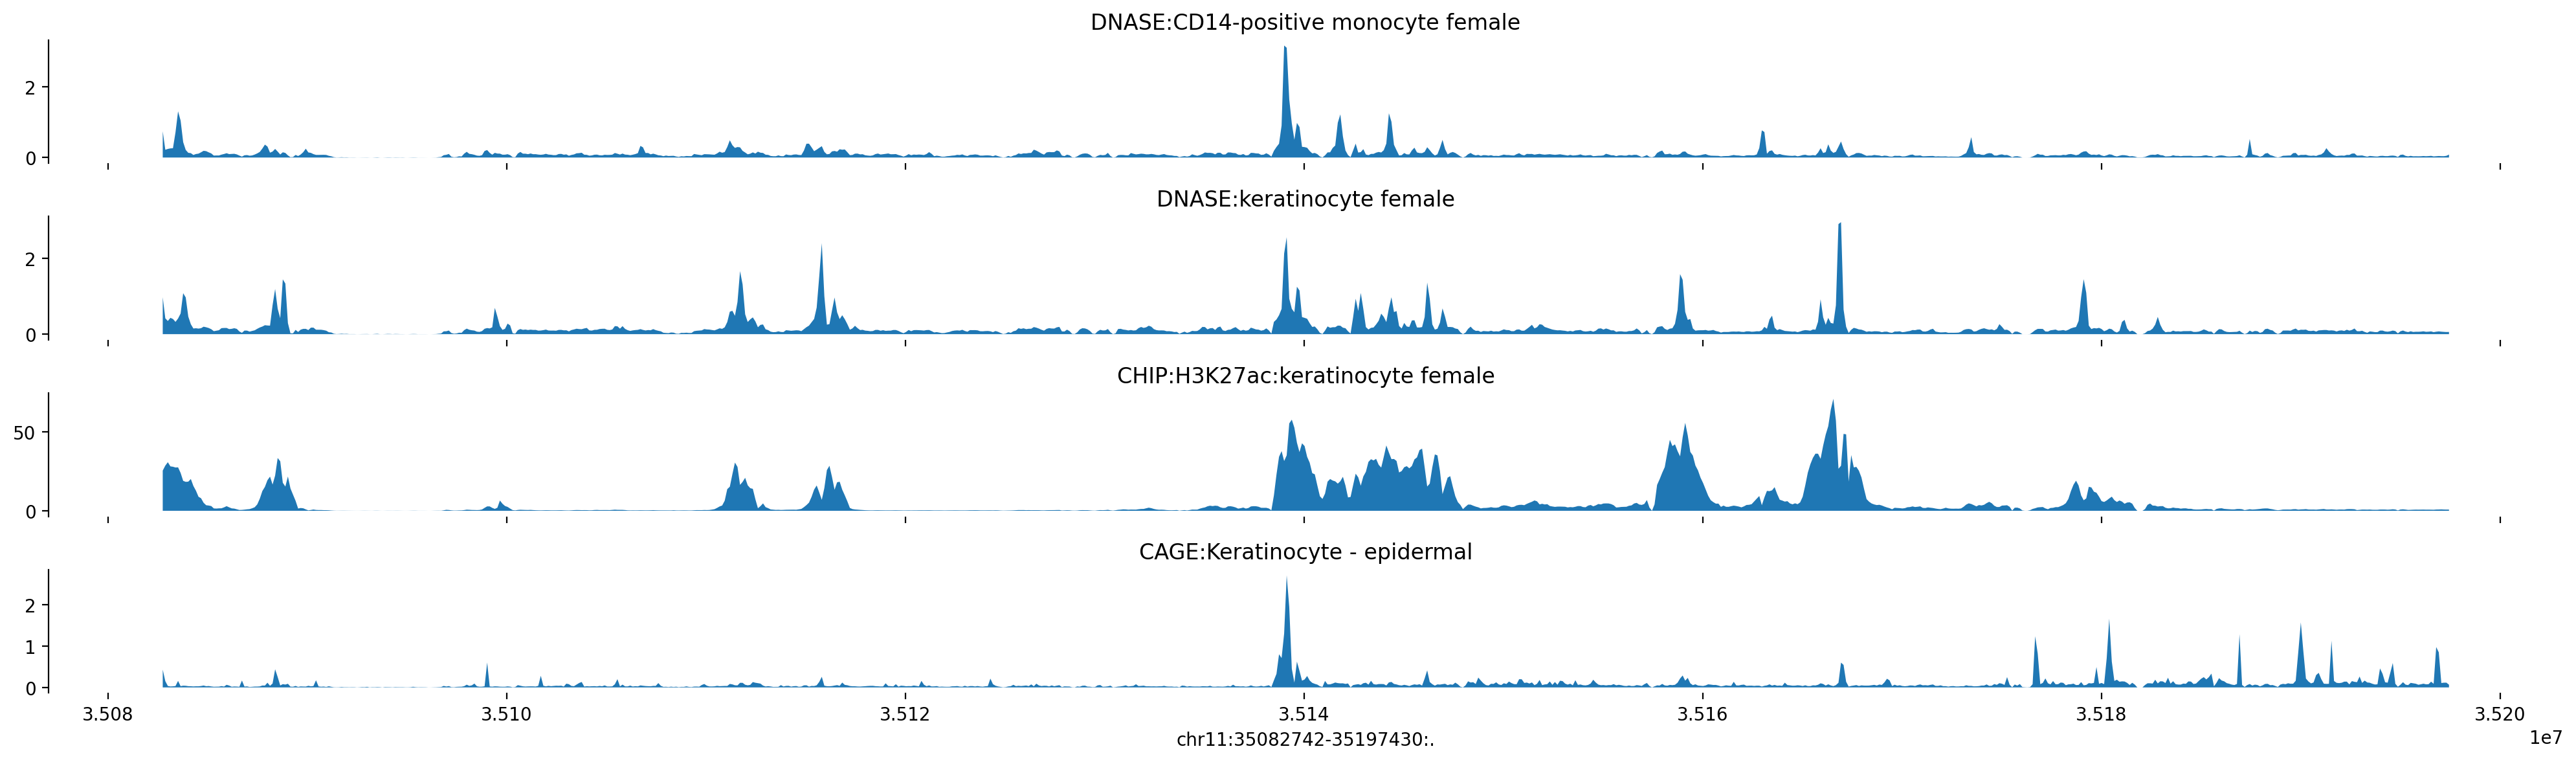

In [27]:
# @title Plot tracks
tracks = {'DNASE:CD14-positive monocyte female': predictions[:, 41],
          'DNASE:keratinocyte female': predictions[:, 42],
          'CHIP:H3K27ac:keratinocyte female': predictions[:, 706],
          'CAGE:Keratinocyte - epidermal': np.log10(1 + predictions[:, 4799])}
plot_tracks(tracks, target_interval)

## **Contribution scores example**

In [28]:
# @title Compute contribution scores
target_interval = kipoiseq.Interval('chr12', 54_223_589, 54_338_277)  # @param

sequence_one_hot = one_hot_encode(fasta_extractor.extract(target_interval.resize(SEQUENCE_LENGTH)))
predictions = model.predict_on_batch(sequence_one_hot[np.newaxis])['human'][0]

target_mask = np.zeros_like(predictions)
for idx in [447, 448, 449]:
  target_mask[idx, 4828] = 1
  target_mask[idx, 5111] = 1

# This will take some time since tf.function needs to get compiled.
contribution_scores = model.contribution_input_grad(sequence_one_hot.astype(np.float32), target_mask).numpy()
pooled_contribution_scores = tf.nn.avg_pool1d(np.abs(contribution_scores)[np.newaxis, :, np.newaxis], 128, 128, 'VALID')[0, :, 0].numpy()[1088:-1088]

# tf.nn.avg_pool1d(..., ksize=128, strides=128, padding='VALID')
# splits the 393 kb sequence into non-overlapping 128 bp bins
# averages attribution within each bin

# predictions.shape = (num_bins, num_tracks)
# num_bins ≈ 896 (binned along the 393 kb window)
# num_tracks = 5313 (CAGE/DNase/ChIP/etc.)

# think of predictions[bin, track].
# target_mask has the same shape as predictions:
# target_mask.shape == (num_bins, num_tracks)


# It is mostly zeros, but you set a few entries to 1:
# bins: 447, 448, 449 (three adjacent bins near the center)
# tracks: 4828 and 5111 (two particular output tracks)

# So you are saying:

# Explain the DNA bases that influence the model’s output
# for tracks 4828 & 5111, specifically at bins 447–449.

# 4828	0	CNhs11250	/home/drk/tillage/datasets/human/cage/fantom/CNhs11250/summary/coverage.w5	384	1	sum	CAGE:chronic myelogenous leukemia cell line:K562
# 5111	0	CNhs12336	/home/drk/tillage/datasets/human/cage/fantom/CNhs12334/summary/coverage.w5	384	1	sum	CAGE:chronic myelogenous leukemia cell line:K562 ENCODE, biol_

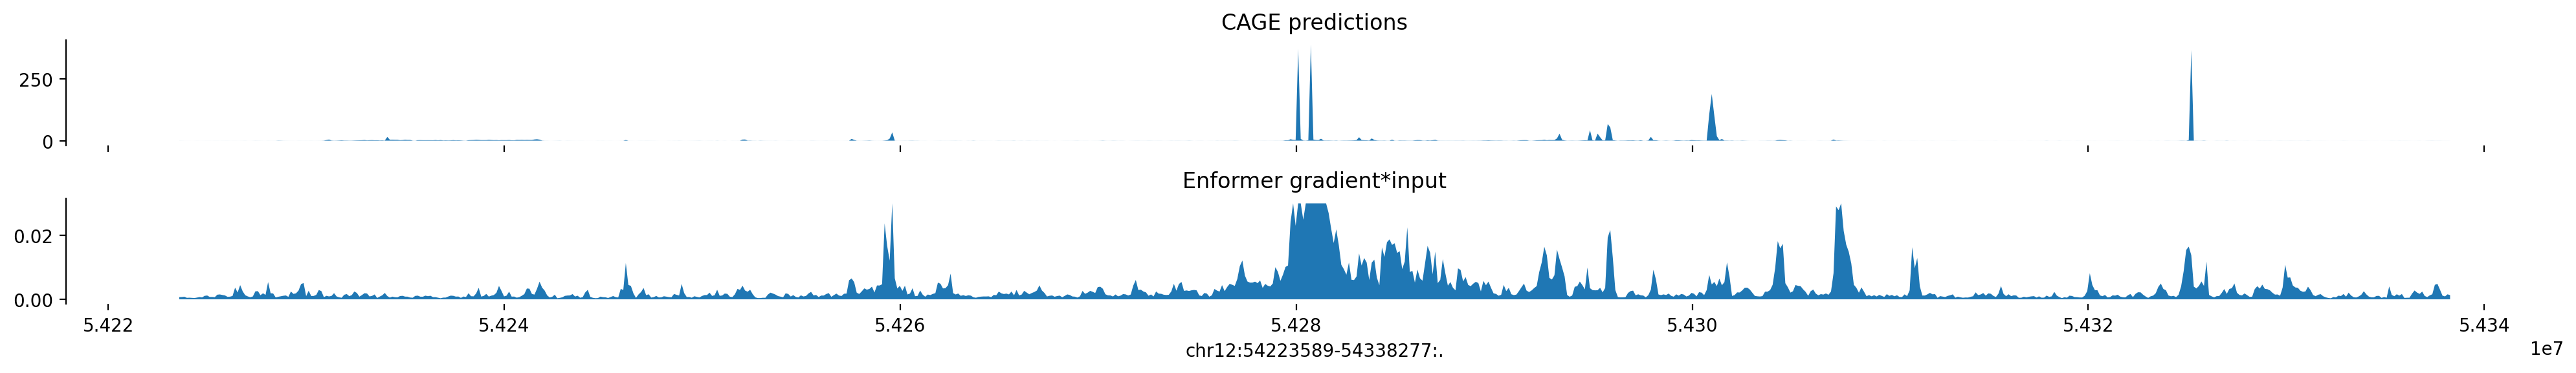

In [29]:
tracks = {'CAGE predictions': predictions[:, 4828],
          'Enformer gradient*input': np.minimum(pooled_contribution_scores, 0.03)}
plot_tracks(tracks, target_interval);

### **Mathematically:**

1. Compute gradient: ∂(output) / ∂(input)
   "How much does output change if we change this input?"

2. Multiply by input: gradient × input
  "Weight the gradient by the actual input value"

3. Sum across channels (ACGT)
   "Get one score per base position"

### **Result:**

High positive value = "This base INCREASES the target predictions"

High negative value = "This base DECREASES the target predictions"

Near zero = "This base doesn't matter much"

pooled_contribution_scores.shape

### **Pooling:**

Taking groups of values and summarizing them into a single value (usually by averaging or taking the max).

Think of it like zooming out on a high-resolution image to see the big picture.

pool_size = 128   # Take 128 consecutive values

strides = 128     # Move window by 128 (non-overlapping)

padding = 'VALID' # No padding at edges



#### One importance score per output bin
#### Each value represents:
#### "How important is the input DNA at this position for predicting the target tracks?"

```
Complete Pipeline Visualization
```
Step 1: DNA Sequence
[ACGT...] (393,216 bases)

        ↓ contribution_input_grad

Step 2: Contribution Scores
[0.023, -0.015, 0.001, ...] (393,216 scores)
 ↑ Important bases have high magnitude

        ↓ np.abs() - take absolute value

Step 3: Absolute Contributions
[0.023, 0.015, 0.001, ...] (393,216 scores)

        ↓ avg_pool1d(128, 128)

Step 4: Pooled (smooth)
[0.018, 0.012, ...] (3,072 bins of 128bp each)

        ↓ [1088:-1088] - trim edges

Step 5: Final Trimmed
[0.018, 0.012, ...] (896 bins)
 ↑ Matches Enformer output resolution

## **Variant scoring example**

In [30]:
# @title Score the variant
variant = kipoiseq.Variant('chr16', 57025062, 'C', 'T', id='rs11644125')  # @param

# Center the interval at the variant
interval = kipoiseq.Interval(variant.chrom, variant.start, variant.start).resize(SEQUENCE_LENGTH)
seq_extractor = kipoiseq.extractors.VariantSeqExtractor(reference_sequence=fasta_extractor)
center = interval.center() - interval.start

reference = seq_extractor.extract(interval, [], anchor=center)
alternate = seq_extractor.extract(interval, [variant], anchor=center)

# Make predictions for the refernece and alternate allele
reference_prediction = model.predict_on_batch(one_hot_encode(reference)[np.newaxis])['human'][0]
alternate_prediction = model.predict_on_batch(one_hot_encode(alternate)[np.newaxis])['human'][0]

In [31]:
reference[196606:196611]

'CCCCC'

In [32]:
alternate[196606:196611]

'CCTCC'

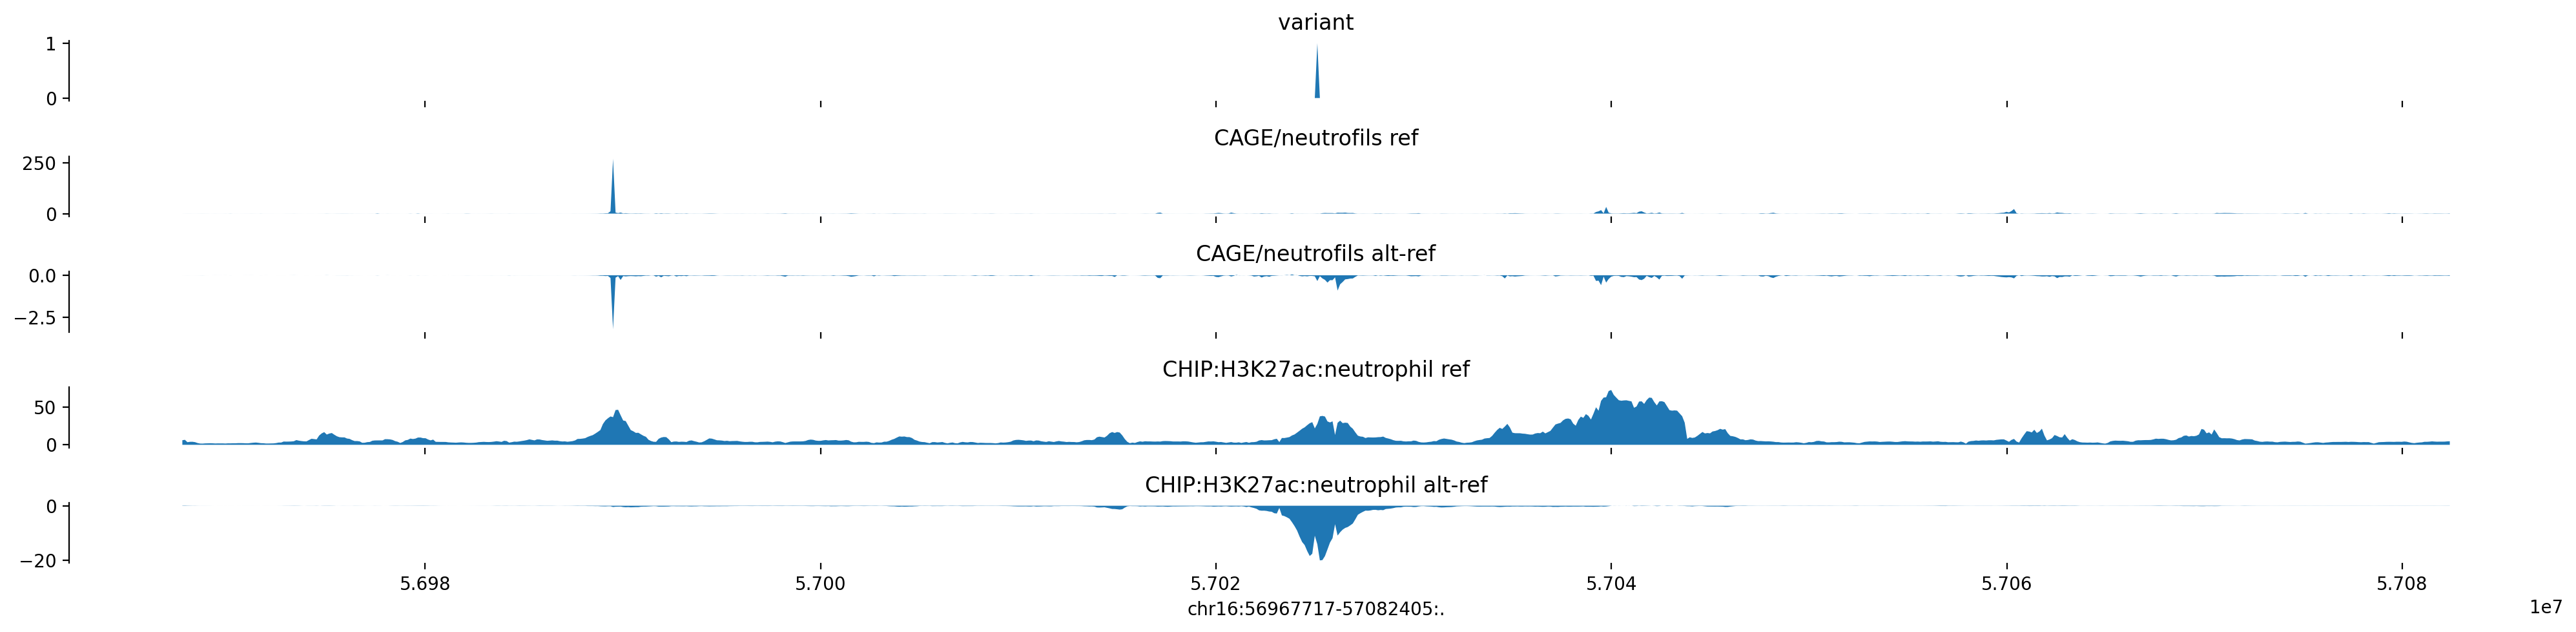

In [33]:
# @title Visualize some tracks
variant_track = np.zeros_like(reference_prediction[:, 0], dtype=bool)
variant_track[variant_track.shape[0] // 2] = True
tracks = {'variant': variant_track,
          'CAGE/neutrofils ref': reference_prediction[:, 4767],
          'CAGE/neutrofils alt-ref': alternate_prediction[:, 4767] - reference_prediction[:, 4767],
          'CHIP:H3K27ac:neutrophil ref': reference_prediction[:, 2280],
          'CHIP:H3K27ac:neutrophil alt-ref': alternate_prediction[:, 2280] - reference_prediction[:, 2280],
          }

plot_tracks(tracks, interval.resize(reference_prediction.shape[0] * 128), height=1)

# ChIP:H3K27ac / neutrophil — alt − ref
# Difference track for H3K27ac: alt − ref

# The deep negative valley centered on the variant means:
# The alternate allele strongly reduces predicted H3K27ac.

# In other words, the variant weakens enhancer/promoter activity.

## **Score variants in a VCF file**

In [34]:
enformer_score_variants = EnformerScoreVariantsPCANormalized(model_path, transform_path, num_top_features=20)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid


#### **Report top 20 PCs**

Enformer predicts 5,313 different genomic assays (the tracks)
For 896 genomic bins (spatial positions)
This is just what Enformer outputs - it's trained to predict all these tracks

#### **Calculate effect of variant**

variant_effect = alternate_prediction - reference_prediction

#### **Shape: (896, 5313)**

#### **Example at center bin (bin 448):**

variant_effect[448, 0]    = 0.02   # Effect on DNASE:CD14+ monocyte

variant_effect[448, 41]   = -0.15  # Effect on DNASE:keratinocyte

variant_effect[448, 706]  = 0.30   # Effect on H3K27ac:keratinocyte

variant_effect[448, 4828] = -0.05  # Effect on CAGE:monocyte

#### **... 5,309 more values**

So we have:

896 bins × 5,313 tracks = 4,760,448 total values! 😱

Enformer's output layer literally has 5,313 neurons (one per track):

#### **Simplified Enformer architecture:**

Input: (batch, 393216, 4)  # DNA sequence
   ↓
[Convolutions]
   ↓
[Transformer blocks]
   ↓
Output: (batch, 896, 5313)  # 5,313 track predictions
                       ↑
                  One output per track!

Breaking Down the 5,313 Values

Each Value = Effect on One Specific Assay

#### **Example variant scores after averaging:**

scores[0]    =  0.02   # DNASE:CD14-positive monocyte female

scores[1]    = -0.01   # DNASE:CD14-positive monocyte male

scores[41]   =  0.15   # DNASE:CD14-positive monocyte female (replicate)

scores[42]   = -0.30   # DNASE:keratinocyte female

scores[706]  =  0.45   # CHIP:H3K27ac:keratinocyte female

scores[2280] = -0.12   # CHIP:H3K27ac:neutrophil female

scores[4767] =  0.08   # CAGE:neutrophil

scores[4828] = -0.15   # CAGE:monocyte - CD14+

scores[5111] =  0.22   # CAGE:T cell - CD8+

#### **... continues for all 5,313 tracks**

The Problem: 5,313 is Too Many

Why We Can't Use All 5,313 Directly

Problem 1: Interpretation Overload

Problem 2: High Correlation

Problem 3: Visualization Impossible

Problem 4: Comparison Difficult

#### **Example with batch_size=1:**

#### **Reference predictions:**

ref = [[[0.1, 0.2, ...],  # Bin 0, all 5313 tracks

       [0.1, 0.2, ...],   # Bin 1, all 5313 tracks

       ...

       [0.1, 0.2, ...]]]  # Bin 895, all 5313 tracks

#### **Shape: (1, 896, 5313)**

#### **Alternate predictions:**

alt = [[[0.12, 0.18, ...],  # Bin 0, all 5313 tracks

       [0.11, 0.19, ...],   # Bin 1, all 5313 tracks

       ...

       [0.09, 0.22, ...]]]  # Bin 895, all 5313 tracks

#### **Shape: (1, 896, 5313)**

#### **Average across bins for each track:**

ref_avg = ref.mean(axis=1)  # Shape: (1, 5313)

alt_avg = alt.mean(axis=1)  # Shape: (1, 5313)

#### **Difference:**

effect = alt_avg - ref_avg  # Shape: (1, 5313)

#### **This gives 5,313 values!**
```



###  **Visual Representation:**

#### **Why We Get 5,313 Values**

```
Starting point:
Enformer outputs 5,313 tracks for 896 bins

Reference sequence:
┌─────────────────────────────────────┐
│ Bin 0:   [track0, track1, ..., track5312] │
│ Bin 1:   [track0, track1, ..., track5312] │
│ ...                                  │
│ Bin 895: [track0, track1, ..., track5312] │
└─────────────────────────────────────┘
Shape: (896, 5313)

Alternate sequence:
┌─────────────────────────────────────┐
│ Bin 0:   [track0, track1, ..., track5312] │
│ Bin 1:   [track0, track1, ..., track5312] │
│ ...                                  │
│ Bin 895: [track0, track1, ..., track5312] │
└─────────────────────────────────────┘
Shape: (896, 5313)

Difference (per bin):
┌─────────────────────────────────────┐
│ Bin 0:   [Δtrack0, Δtrack1, ..., Δtrack5312] │
│ Bin 1:   [Δtrack0, Δtrack1, ..., Δtrack5312] │
│ ...                                  │
│ Bin 895: [Δtrack0, Δtrack1, ..., Δtrack5312] │
└─────────────────────────────────────┘
Shape: (896, 5313)

Average across bins (↓):
┌─────────────────────────────────────┐
│ [avg_Δtrack0, avg_Δtrack1, ..., avg_Δtrack5312] │
└─────────────────────────────────────┘
Shape: (5313,)  ← THIS IS WHY WE GET 5,313 VALUES!

1. Enformer predicts 5,313 tracks (by design)
   ↓
2. We get predictions for reference and alternate
   Both shape: (896, 5313)
   ↓
3. We compute difference: alt - ref
   Shape: (896, 5313)
   ↓
4. We average across 896 bins
   Shape: (5313,)
   ↓
5. Result: 5,313 values (one per track)

Each value = average effect on that track across the region
```

**The 5,313 comes from:**
- **Enformer's training data** (5,313 tracks in Basenji2)
- **Enformer's architecture** (5,313 output neurons)
- **Not a choice** - it's just what Enformer outputs!

**Why we use PCA to reduce to 20:**
- 5,313 is too many to interpret
- Many tracks are correlated (redundant)
- 20 PCs capture most information (80-90%)
- Much more practical for analysis

**Think of it like:**
```
5,313 tracks = Taking 5,313 different measurements of the same item

20 PCs = Summarizing those measurements into 20 key patterns

#### **Example with one variant:**

inputs = {

    'ref': reference_sequence_one_hot,  # (1, 393216, 4)
  
    'alt': alternate_sequence_one_hot   # (1, 393216, 4)

}

#### **Raw scoring process:**

ref_pred = enformer.predict(inputs['ref'])     # (1, 896, 5313)

alt_pred = enformer.predict(inputs['alt'])     # (1, 896, 5313)

#### **Average across bins:**

ref_avg = ref_pred.mean(axis=1)  # (1, 5313)

alt_avg = alt_pred.mean(axis=1)  # (1, 5313)

#### **Difference:**

scores = alt_avg - ref_avg  # (1, 5313)

#### **Example values (raw, unnormalized):**

scores = [[

    0.5,      # Track 0: DNASE effect

    125.3,    # Track 1: Some track with large values

    0.002,    # Track 2: Small effect

    -890.7,   # Track 3: Large negative effect

    ...       # 5,309 more values

]]

**Problem with raw scores:**

Wildly different scales

Some tracks have huge values (hundreds)

Some have tiny values (0.001)

Can't compare directly

**Apply Transformation Pipeline:**

transformed = self._transform.transform(scores)

Input:  (batch, 5313)

Output: (batch, 500)

#### **Step 1 in pipeline:** **RobustScaler**

scaler1 = self._transform.named_steps['scaler1']

scores_normalized1 = scaler1.transform(scores)

**What RobustScaler does**

For each track, normalize using median and IQR:

normalized_value = (value - median) / IQR

Example (Track 0: DNASE)

From training data, this track has:

median_track0 = 0.48

IQR_track0 = 0.15

#### **Raw score for our variant:**

raw_track0 = 0.5

#### **Normalized value:**

normalized_track0 = (raw_track0 - median_track0) / IQR_track0

normalized_track0  # 0.133

Across all 5,313 tracks (illustrative)

Track 0:  0.5    →  0.133

Track 1:  125.3  →  0.087   (median=120, IQR=80)

Track 2:  0.002  → -0.200  (median=0.005, IQR=0.015)

Track 3: -890.7  → -1.500  (median=-800, IQR=60)
...

**Why RobustScaler?**

Uses median instead of mean → robust to outliers

Uses IQR instead of standard deviation → robust to heavy tails

Well-suited for genomic tracks, which often contain extreme values

Result after first scaling

scores_normalized1.shape

(batch, 5313)

All tracks now on a comparable scale (typically ~ -3 to +3)

### **Step 2 in pipeline: PCA**

pca = self._transform.named_steps['pca']

pca_scores = pca.transform(scores_normalized1)

What PCA does ▶

#### **PCA finds 500 principal components (PC1, PC2, ..., PC500)**

#### **Each PC is a linear combination of the 5,313 tracks**

#### Mathematically:

PC1   = w1_0   * track0 + w1_1   * track1 + ... + w1_5312   * track5312

PC2   = w2_0   * track0 + w2_1   * track1 + ... + w2_5312   * track5312

...


PC500 = w500_0 * track0 + w500_1 * track1 + ... + w500_5312 * track5312

The weights w are learned during training

Each PC captures maximum remaining variance

Concrete example :

#### **Normalized input scores (5,313 values)**

scores_normalized1 = [0.133, 0.087, -0.200, -1.500, ...]

#### **PCA weights (learned during training)**

PC1_weights = [0.05, 0.03, -0.02, 0.08, ...]

PC2_weights = [0.02, -0.04, 0.06, -0.01, ...]

#### **Compute PC scores**

PC1 = sum(s * w for s, w in zip(scores_normalized1, PC1_weights))

PC2 = sum(s * w for s, w in zip(scores_normalized1, PC2_weights))

PC1  # 2.35
PC2  # -0.58

#### **Final PCA output**

pca_scores = [2.35, -0.58, 1.12, 0.33, ..., 0.05]  # 500 values

Conceptual meaning of PCs

PC1 (~20% variance):

  "Overall regulatory impact"

  + high  → increased activity across many tracks

  - low   → decreased activity across many tracks

PC2 (~15% variance):

  "Immune vs non-immune specificity"

  + high  → immune-related effects

  - low   → non-immune effects

PC3–PC500:

  Progressively more subtle regulatory patterns

Result after PCA

pca_scores.shape

(batch, 500)

#### **Dimensionality reduced: 5,313 → 500**


### **Step 3 in pipeline: Second RobustScaler**

scaler2 = self._transform.named_steps['scaler2']

transformed = scaler2.transform(pca_scores)

**Why another scaler?**

After PCA, different PCs have different variances:

PC1:   mean=0, std=4.5

PC2:   mean=0, std=3.2

PC3:   mean=0, std=1.8

...

PC500: mean=0, std=0.1

Second RobustScaler normalizes each PC by its own IQR:

PC1:  2.35  →  0.52

PC2: -0.58  → -0.18

PC3:  1.12  →  0.62

...


Puts all PCs on the same scale

Makes downstream comparison and interpretation easier

Result after second scaling

transformed.shape

##### (batch, 500)

### **Step 4: Return Top N Features**

return transformed[:, :self._num_top_features]

Input shape:  (batch, 500)

Output shape: (batch, 20)   # if num_top_features = 20

What this does

#### **Full transformed vector (500 PCs)**

transformed = [
    [0.52, -0.18, 0.62, 0.33, ..., 0.05]
]

#### **Keep only the top 20 PCs**

result = transformed[:, :20]

These are the most informative components:

- PC1 explains the most variance

- PC20 still captures meaningful signal

- PC21–PC500 contribute diminishing returns


### **Complete Pipeline Visualization**

```
INPUT: Variant sequences
(ref and alt)
      ↓
┌─────────────────────────────────────┐
│ EnformerScoreVariantsRaw            │
│                                     │
│ 1. Predict ref → (896, 5313)       │
│ 2. Predict alt → (896, 5313)       │
│ 3. Average bins: mean(axis=1)      │
│ 4. Difference: alt - ref           │
└─────────────────────────────────────┘
      ↓
Raw scores: (batch, 5313)
[0.5, 125.3, 0.002, -890.7, ...]
      ↓
┌─────────────────────────────────────┐
│ RobustScaler #1                     │
│ Normalize each track using          │
│ median and IQR from training        │
└─────────────────────────────────────┘
      ↓
Normalized: (batch, 5313)
[0.133, 0.087, -0.200, -1.500, ...]
      ↓
┌─────────────────────────────────────┐
│ PCA                                 │
│ Project onto 500 principal          │
│ components learned from training    │
└─────────────────────────────────────┘
      ↓
PC scores: (batch, 500)
[2.35, -0.58, 1.12, 0.33, ..., 0.05]
      ↓
┌─────────────────────────────────────┐
│ RobustScaler #2                     │
│ Normalize PC scores using           │
│ median and IQR from training        │
└─────────────────────────────────────┘
      ↓
Normalized PCs: (batch, 500)
[0.52, -0.18, 0.62, 0.33, ..., 0.01]
      ↓
┌─────────────────────────────────────┐
│ Select top N features               │
│ Keep only first num_top_features    │
└─────────────────────────────────────┘
      ↓
OUTPUT: (batch, 20)
[0.52, -0.18, 0.62, 0.33, 0.15, -0.08,
 0.25, 0.42, -0.31, 0.18, 0.09, -0.15,
 0.22, 0.38, -0.12, 0.05, 0.19, 0.28,
 -0.09, 0.12]

**Summary :**

EnformerScoreVariantsPCANormalized pipeline:

**1. Raw scoring (5,313 values)**

   ↓ Enformer predictions + averaging
   
**2. First normalization (5,313 values, normalized)**

   ↓ RobustScaler on tracks
   
**3. PCA projection (500 values)**

   ↓ Dimensionality reduction
   
**4. Second normalization (500 values, normalized)**

   ↓ RobustScaler on PCs
   
**5. Feature selection (20 values)**

   ↓ Keep top components

**RESULT: 20 interpretable, normalized scores**

In [35]:
# Score the first 5 variants from ClinVar

# Lower-dimensional scores (20 PCs)

it = variant_centered_sequences(clinvar_vcf,
                                sequence_length=SEQUENCE_LENGTH,
                                gzipped=True,
                                chr_prefix='chr')

# A generator that yields one variant at a time

example_list = []
for i, example in enumerate(it):
  if i >= 5:
    break
  variant_scores = enformer_score_variants.predict_on_batch(
      {k: v[tf.newaxis] for k,v in example['inputs'].items()})[0]
  variant_scores = {f'PC{i}': score for i, score in enumerate(variant_scores)}
  example_list.append({**example['metadata'],
                       **variant_scores})
  if i % 2 == 0:
    print(f'Done {i}')
df = pd.DataFrame(example_list)
df

Done 0
Done 2
Done 4


,chrom,pos,id,ref,alt,PC0,PC1,PC2,PC3,PC4,...,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
0,chr1,66926,3385321,AG,A,-836.237549,-115.085320,-105.809944,364.559235,4.265784,...,75.144341,30.902098,-195.740952,32.180676,-10.327229,206.255234,268.676849,73.871666,38.847790,-91.002083
1,chr1,69134,2205837,A,G,-6.852872,2.669405,-4.316309,8.134164,1.958050,...,1.205200,-0.960273,-5.569252,1.713736,-2.128435,4.346044,2.271957,-0.669898,-1.724406,0.866112
2,chr1,69241,4562067,C,T,6.966006,-2.932452,3.922260,-6.039390,-1.749590,...,0.743575,-2.115065,8.682478,-2.703931,1.162040,-3.585398,0.872532,0.846446,2.030529,-0.563625
3,chr1,69308,3925305,A,G,-3.106230,6.537751,-6.527922,9.257462,2.520607,...,-2.250191,1.352216,-11.926293,3.032960,-3.692279,4.019841,-1.548934,0.541993,-1.782495,0.202217
4,chr1,69314,3205580,T,G,-4.215656,7.097936,-7.932463,10.099150,2.198800,...,-1.198010,-0.135540,-11.210992,2.689376,-4.298342,2.695441,0.535328,-2.240205,-5.335645,1.783928


#### **What PCA Components Actually Represent :**

PCA discovers hidden patterns that explain the data:

#### **Example: What Each PC Might Mean**

PC0 (explains 20% of variance):
"Overall regulatory impact"
- High positive: Variant increases activity broadly
- High negative: Variant decreases activity broadly
- Near zero: Variant has balanced or minimal effect

#### **Why this emerges:**

Many tracks are correlated (when one goes up, others go up)
: PC1 captures this common "up/down" pattern

#### ─────────────────────────────────────────────

#### **PC1 (explains 15% of variance):**

"Immune vs non-immune cell specificity"
- High positive: Effect mainly in immune cells
- High negative: Effect mainly in non-immune cells
- Near zero: No cell-type specificity

Why this emerges:

Immune cell tracks correlate with each other
Non-immune tracks correlate with each other
But immune and non-immune are anti-correlated
PC2 captures this distinction

#### ─────────────────────────────────────────────

#### **PC2 (explains 10% of variance):**
"Chromatin state: open vs closed"
- High positive: Variant opens chromatin
- High negative: Variant closes chromatin

#### ─────────────────────────────────────────────

#### **PC3 (explains 8% of variance):**
"Enhancer vs promoter effects"
- High positive: Affects enhancers more
- High negative: Affects promoters more

#### ─────────────────────────────────────────────

#### **PC4-PC19: More subtle patterns**
- Brain-specific effects
- Sex-specific effects
- Cell division/development
- Tissue-specific patterns
- etc.

**Concrete Example: Two Variants**

**Without PCA (Raw Scores)**

#### **Variant A (affects immune cells):**

DNASE:monocyte:        0.45

DNASE:T-cell:          0.42

DNASE:neutrophil:      0.48

CHIP:H3K27ac:monocyte: 0.50

CAGE:monocyte:         0.38

DNASE:keratinocyte:    0.01  # Not immune

DNASE:neuron:          0.02  # Not immune

DNASE:hepatocyte:     -0.01  # Not immune

... # 5,305 more values

#### **Question: "What does variant A do?"**

#### **Answer: "Umm... it affects many tracks...**

mostly high in... let me see...

monocytes and T-cells and...

this will take a while..." 😰

**With PCA (20 Components)**

#### **Variant A (affects immune cells):**

PC0:  2.3   ← VERY HIGH: Strong overall effect

PC1:  1.8   ← HIGH POSITIVE: Immune-cell specific

PC2:  0.5   ← Moderate: Opens chromatin

PC3: -0.2   ← Small: Slight promoter preference

PC4:  0.1   ← Tiny: Minimal developmental effect

...

PC19: 0.05  ← Tiny: Negligible

#### **Question: "What does variant A do?"**

#### **Answer:**

"Strong regulatory impact (PC0=2.3),

specifically in immune cells (PC1=1.8),

opens chromatin (PC2=0.5)" 💡

#### Clear, concise, interpretable!

In [36]:
# INITIALIZE THE SCORER FIRST!
# This connects your local model and the transform pickle file
enformer_score_variants_all = EnformerScoreVariantsNormalized(model_path, transform_path)

# 2. RUN THE VARIANT SCORING
# Score the first 5 variants from ClinVar (All Scores)
it = variant_centered_sequences(clinvar_vcf,
                                sequence_length=SEQUENCE_LENGTH,
                                gzipped=True,
                                chr_prefix='chr')

example_list = []
for i, example in enumerate(it):
  if i >= 5:
    break

  # Predict on the batch using the scorer we just defined
  variant_scores = enformer_score_variants_all.predict_on_batch(
      {k: v[tf.newaxis] for k,v in example['inputs'].items()})[0]

  variant_scores = {f'{i}_{name[:20]}': score for i, (name, score) in enumerate(zip(df_targets.description, variant_scores))}

  example_list.append({**example['metadata'],
                       **variant_scores})

  if i % 2 == 0:
    print(f'Done {i}')

df = pd.DataFrame(example_list)
df

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid

Done 0
Done 2
Done 4


,chrom,pos,id,ref,alt,0_DNASE:cerebellum mal,1_DNASE:frontal cortex,2_DNASE:chorion,3_DNASE:Ishikawa treat,4_DNASE:GM03348,...,"5303_CAGE:thalamus, adult","5304_CAGE:putamen, adult,",5305_CAGE:parietal cortex,5306_CAGE:medial temporal,5307_CAGE:squamous cell l,5308_CAGE:epithelioid sar,5309_CAGE:squamous cell l,5310_CAGE:gastric cancer,5311_CAGE:carcinoid cell,5312_CAGE:lung adenocarci
0,chr1,66926,3385321,AG,A,-109.098091,-164.118195,-175.025589,-122.875908,-200.096085,...,-76.645081,-91.365517,-96.492783,-46.976677,-687.878967,-603.518311,-908.354431,-393.308990,-493.594971,-797.600647
1,chr1,69134,2205837,A,G,-1.037609,-2.017236,-2.343294,-1.186812,-1.827675,...,-0.104983,-0.415157,-0.439686,0.371041,-2.760409,-5.160244,-6.990657,-2.698676,-1.703075,-3.474150
2,chr1,69241,4562067,C,T,4.026999,5.247922,4.653893,5.451652,4.422249,...,1.557902,1.042081,1.229193,0.605427,2.841223,4.272368,5.977798,4.137948,1.144507,2.649486
3,chr1,69308,3925305,A,G,-4.011436,-6.483379,-5.717808,-7.649611,-6.533495,...,-1.002793,-0.288574,-0.714022,-0.216245,-0.204843,-0.894182,-0.558929,-1.159587,-0.000174,-0.170435
4,chr1,69314,3205580,T,G,-3.195827,-5.544322,-4.236098,-4.588369,-4.865565,...,-0.472903,-0.727496,-0.858776,-0.018861,-4.841897,-1.334301,-2.619319,-2.531656,-3.672360,-4.750988


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid

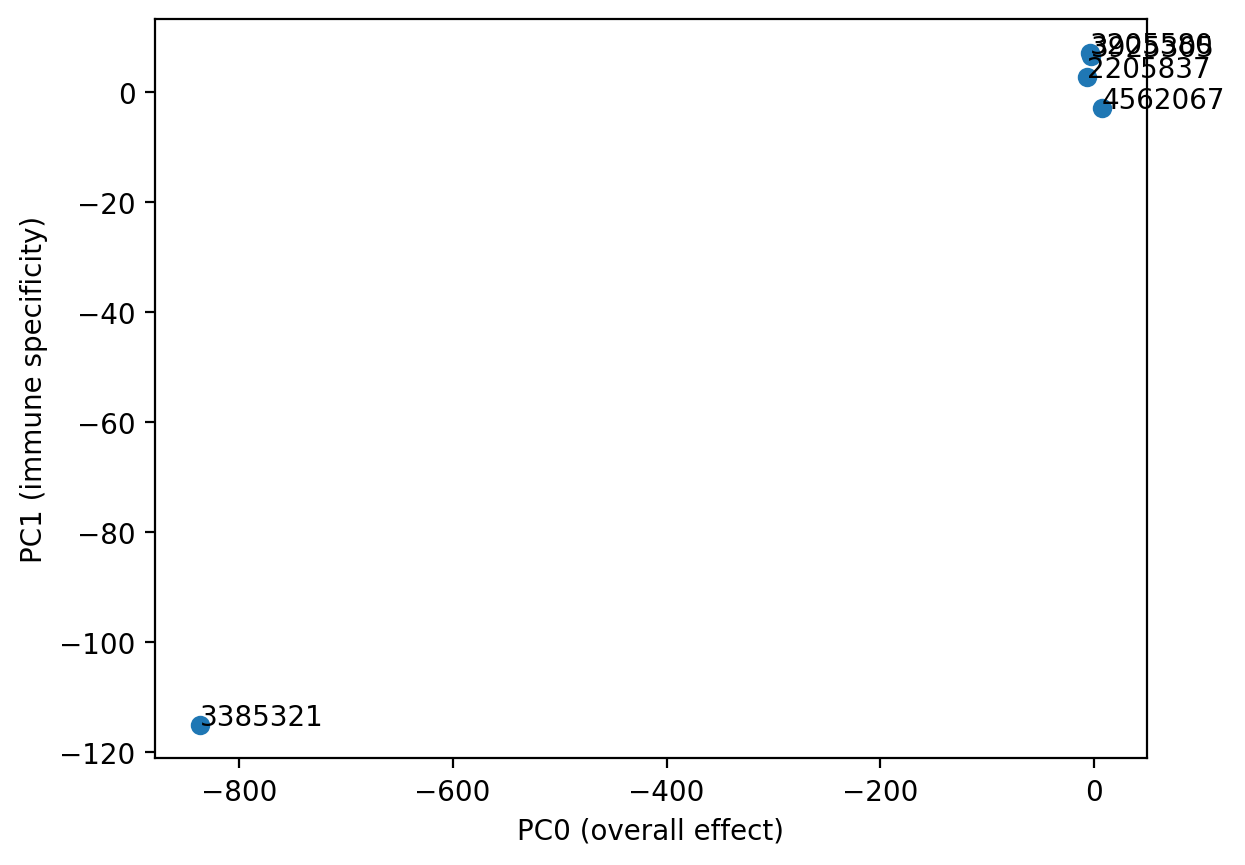

In [37]:
# INITIALIZE THE PCA SCORER
# (This gives you the 20 PCs instead of the 5,313 raw tracks)
enformer_score_variants_pca = EnformerScoreVariantsPCANormalized(model_path, transform_path, num_top_features=20)

# 2. RUN THE VARIANT SCORING
it = variant_centered_sequences(clinvar_vcf,
                                sequence_length=SEQUENCE_LENGTH,
                                gzipped=True,
                                chr_prefix='chr')

example_list = []
for i, example in enumerate(it):
  if i >= 5:
    break

  # Predict using the PCA scorer
  variant_scores = enformer_score_variants_pca.predict_on_batch(
      {k: v[tf.newaxis] for k,v in example['inputs'].items()})[0]

  # Label the columns as PC0, PC1, etc.
  variant_scores = {f'PC{i}': score for i, score in enumerate(variant_scores)}

  example_list.append({**example['metadata'],
                       **variant_scores})

# Create the DataFrame with PC columns
df_pca = pd.DataFrame(example_list)

# 3. PLOT THE DATA
# (Using df_pca so it doesn't conflict with your other dataframes)
import matplotlib.pyplot as plt

plt.scatter(df_pca['PC0'], df_pca['PC1'])
for idx, row in df_pca.iterrows():
    plt.annotate(row['id'], (row['PC0'], row['PC1']))
plt.xlabel('PC0 (overall effect)')
plt.ylabel('PC1 (immune specificity)')
plt.show()

### Report all 5,313 features (z-score normalized)

In [38]:
enformer_score_variants_all = EnformerScoreVariantsNormalized(model_path, transform_path)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 0.23.2 when using version 1.6.1. This might lead to breaking code or invalid

In [39]:
# Score the first 5 variants from ClinVar

# All Scores

it = variant_centered_sequences(clinvar_vcf,
                                sequence_length=SEQUENCE_LENGTH,
                                gzipped=True,
                                chr_prefix='chr')
example_list = []
for i, example in enumerate(it):
  if i >= 5:
    break
  variant_scores = enformer_score_variants_all.predict_on_batch(
      {k: v[tf.newaxis] for k,v in example['inputs'].items()})[0]
  variant_scores = {f'{i}_{name[:20]}': score for i, (name, score) in enumerate(zip(df_targets.description, variant_scores))}
  example_list.append({**example['metadata'],
                       **variant_scores})
  if i % 2 == 0:
    print(f'Done {i}')
df = pd.DataFrame(example_list)
df

Done 0
Done 2
Done 4


,chrom,pos,id,ref,alt,0_DNASE:cerebellum mal,1_DNASE:frontal cortex,2_DNASE:chorion,3_DNASE:Ishikawa treat,4_DNASE:GM03348,...,"5303_CAGE:thalamus, adult","5304_CAGE:putamen, adult,",5305_CAGE:parietal cortex,5306_CAGE:medial temporal,5307_CAGE:squamous cell l,5308_CAGE:epithelioid sar,5309_CAGE:squamous cell l,5310_CAGE:gastric cancer,5311_CAGE:carcinoid cell,5312_CAGE:lung adenocarci
0,chr1,66926,3385321,AG,A,-109.098091,-164.118195,-175.025589,-122.875908,-200.096085,...,-76.645081,-91.365517,-96.492783,-46.976677,-687.878967,-603.518311,-908.354431,-393.308990,-493.594971,-797.600647
1,chr1,69134,2205837,A,G,-1.037609,-2.017236,-2.343294,-1.186812,-1.827675,...,-0.104983,-0.415157,-0.439686,0.371041,-2.760409,-5.160244,-6.990657,-2.698676,-1.703075,-3.474150
2,chr1,69241,4562067,C,T,4.026999,5.247922,4.653893,5.451652,4.422249,...,1.557902,1.042081,1.229193,0.605427,2.841223,4.272368,5.977798,4.137948,1.144507,2.649486
3,chr1,69308,3925305,A,G,-4.011436,-6.483379,-5.717808,-7.649611,-6.533495,...,-1.002793,-0.288574,-0.714022,-0.216245,-0.204843,-0.894182,-0.558929,-1.159587,-0.000174,-0.170435
4,chr1,69314,3205580,T,G,-3.195827,-5.544322,-4.236098,-4.588369,-4.865565,...,-0.472903,-0.727496,-0.858776,-0.018861,-4.841897,-1.334301,-2.619319,-2.531656,-3.672360,-4.750988


 it returns ALL 5,313 normalized track scores instead of just 20 PCs. Let me explain the differences.

#### **Code Block 1: PCA Version (20 components)**

#### **Code Block 2: Full Version (5,313 tracks)**

#### **3 Key Differences**

#### **Difference 1: Which Model is Used**

#### **VERSION 1 (PCA):**

enformer_score_variants = EnformerScoreVariantsPCANormalized(

    model_path, transform_path, num_top_features=20

)

variant_scores = enformer_score_variants.predict_on_batch(...)

####                     ↑

####            Uses PCA model (returns 20 PCs)

#### **VERSION 2 (Full):**

enformer_score_variants_all = EnformerScoreVariantsNormalized(

    model_path, transform_path

)

variant_scores = enformer_score_variants_all.predict_on_batch(...)

####                     ↑

####            Uses full model (returns 5,313 tracks)


#### **Difference 2: How Dictionary is Created**

#### **Difference 3: Final DataFrame Size 🔑**

#### **WITH PCA (20 values):**

Variant rs123 has:

 - High PC0 (+2.3) = Strong regulatory impact

 - High PC1 (+1.8) = Immune cell specific

 - Medium PC2 (+0.5) = Opens chromatin

 - Low PC3 (-0.2) = Slightly affects promoters"


Variant Prioritization

#### Scenario: **You have 10,000 GWAS variants**

You can only validate 10 in the lab

Which ones do you choose?

#### **WITHOUT PCA:**

#### Look at each of 5,313 tracks for each variant?

#### 10,000 × 5,313 = 53,130,000 numbers to examine

#### Impossible! 😱

#### **WITH PCA:**

#### Sort by |PC0| (overall impact)

top_variants = df.nlargest(10, 'PC0', key=abs)

### **Statistical Analysis**

#### Compare two groups of variants

#### **WITHOUT PCA:**

#### Test 5,313 tracks individually → multiple testing problem

#### Need Bonferroni correction: p < 0.05/5313 = p < 0.00001

#### Loses statistical power

#### **WITH PCA:**

#### Test 20 PCs → manageable multiple testing

#### p < 0.05/20 = p < 0.0025

#### More power to detect differences

from scipy.stats import ttest_ind

#### **Compare pathogenic vs benign variants**

pathogenic_pc0 = pathogenic_variants['PC0']

benign_pc0 = benign_variants['PC0']

t_stat, p_val = ttest_ind(pathogenic_pc0, benign_pc0)

p_val = 0.0001 → Significant difference! ✅

**Machine Learning (Better Models)**

#### **WITHOUT PCA (5,313 features):**

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.fit(X_train_5313, y_train)

#### Problems:

❌ Overfitting (too many features, not enough samples)

❌ Slow training

❌ Needs huge training set

❌ Hard to interpret which features matter

#### **WITH PCA (20 features):**

clf = RandomForestClassifier()
clf.fit(X_train_20, y_train)

#### Benefits:

✅ Less overfitting

✅ Fast training

✅ Works with smaller training set

✅ Easy to interpret: "PC0 and PC1 are most important"

#### Accuracy comparison:

Full model (5,313): 68% accuracy (overfits!)

PCA model (20):     82% accuracy (generalizes better!)

#### **We can reconstruct the track efects from PCA :**
#### (with some information loss)

#### **Start with PCA scores**

pca_scores = [2.3, 1.8, 0.5, ..., 0.1]  # 20 values

#### **Reconstruct approximate track effects**
reconstructed_tracks = pca_inverse_transform(pca_scores)  # (5313,)

#### **Compare to original:**
original_track_42 = 0.48

reconstructed_track_42 = 0.45  # Close, but not exact!

##### Error = 0.48 - 0.45 = 0.03
##### This is the ~15% information loss from using only 20 PCs
